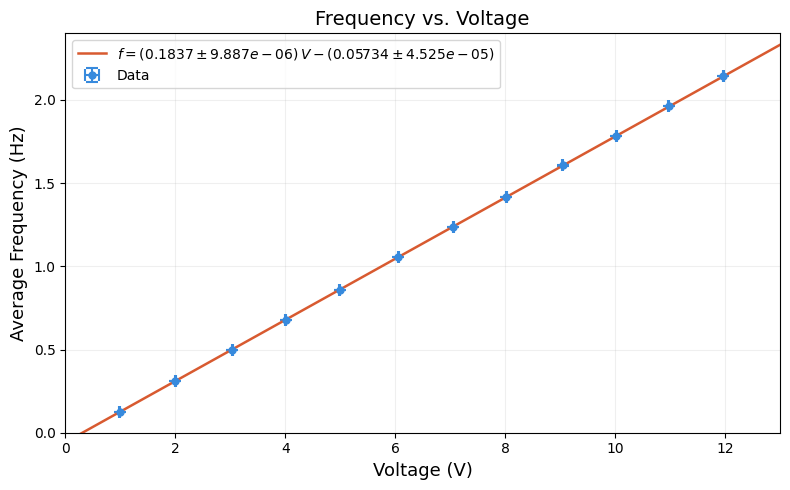

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

data = [
    (0.99,  0.1258,  0.01, 0.0000503),
    (2.00,  0.3096,  0.01, 0.0000639),
    (3.04,  0.4991,  0.01, 0.0000830),
    (4.01,  0.6755,  0.01, 0.000152 ),
    (4.99,  0.8559,  0.01, 0.000244 ),
    (6.06,  1.0559,  0.01, 0.0000743),
    (7.06,  1.237,   0.01, 0.000270 ),
    (8.02,  1.415,   0.01, 0.000241 ),
    (9.05,  1.606,   0.01, 0.000537 ),
    (10.02, 1.785,   0.01, 0.000106 ),
    (10.98, 1.962,   0.01, 0.000340 ),
    (11.97, 2.144,   0.01, 0.000265 ),
]

voltage, frequency, v_err, f_err = zip(*data)
voltage   = np.array(voltage)
frequency = np.array(frequency)
v_err     = np.array(v_err)
f_err     = np.array(f_err)

def linear(V, m, c):
    return m * V + c

popt, pcov = curve_fit(linear, voltage, frequency, sigma=f_err, absolute_sigma=True)
m, c = popt
m_err, c_err = np.sqrt(np.diag(pcov))

V_fit = np.linspace(0, 13, 300)
f_fit = linear(V_fit, m, c)

sign = '+' if c >= 0 else '-'
eq_str = (f'$f = ({m:.4} \\pm {m_err:.4})\\,V '
          f'{sign} ({abs(c):.4} \\pm {c_err:.4})$')

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    voltage, frequency,
    xerr=v_err, yerr=f_err,
    fmt='o', color='#378add',
    ecolor='#378add', elinewidth=1.5,
    capsize=4, capthick=1.5,
    markersize=5, label='Data'
)

ax.plot(V_fit, f_fit, color='#d85a30', linewidth=1.8, label=eq_str)

ax.set_xlabel('Voltage (V)', fontsize=13)
ax.set_ylabel('Average Frequency (Hz)', fontsize=13)
ax.set_title('Frequency vs. Voltage', fontsize=14)
ax.set_xlim(0, 13)
ax.set_ylim(0, 2.4)
ax.grid(True, alpha=0.2)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('frequency_vs_voltage.png', dpi=150)
plt.show()

In [4]:
print(str(np.sqrt(np.abs(pcov))))

[[9.88746990e-06 1.84890535e-05]
 [1.84890535e-05 4.52545644e-05]]
